## Hospital Equipment Intelligence Dashboard

In [2]:
import pandas as pd   #importing packages
import numpy as np

In [3]:
np.random.seed(42)     ##Data Generating

n = 500

df = pd.DataFrame({
    "equipment_id": range(1, n+1),
    "equipment_type": np.random.choice(["Ventilator", "MRI", "X-Ray"], n),
    "usage_hours": np.random.randint(50, 500, n),
    "days_since_maintenance": np.random.randint(1, 100, n),
    "temperature": np.random.uniform(20, 80, n),
    "load": np.random.uniform(0.1, 1.0, n)
})

In [4]:
## Creating pattern-based failures, not random chaos
df["failure"] = (  
    (df["usage_hours"] > 400) |
    (df["days_since_maintenance"] > 70) |
    (df["temperature"] > 60)
).astype(int)

In [5]:
## Adding Imperfection to get some missed values, becoz real data is not always clean
df.loc[df.sample(frac=0.05).index, 'temperature'] = np.nan

In [6]:
## Saving Dataset
df.to_csv("hospital_equipment_data.csv", index=False)

In [7]:
df.head()

,equipment_id,equipment_type,usage_hours,days_since_maintenance,temperature,load,failure
0,1,X-Ray,443,14,35.043840,0.115764,1
1,2,Ventilator,299,59,57.985884,0.319733,0
2,3,X-Ray,196,56,49.656431,0.847789,0
3,4,X-Ray,491,7,54.397663,0.878148,1
4,5,Ventilator,145,3,70.286418,0.791667,1


In [8]:
df.info() #Information of the Data

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   equipment_id            500 non-null    int64  
 1   equipment_type          500 non-null    str    
 2   usage_hours             500 non-null    int32  
 3   days_since_maintenance  500 non-null    int32  
 4   temperature             475 non-null    float64
 5   load                    500 non-null    float64
 6   failure                 500 non-null    int64  
dtypes: float64(2), int32(2), int64(2), str(1)
memory usage: 23.6 KB


In [9]:
df.describe()

,equipment_id,usage_hours,days_since_maintenance,temperature,load,failure
count,500.000000,500.000000,500.000000,475.000000,500.000000,500.000000
mean,250.500000,274.696000,48.232000,49.942011,0.544332,0.606000
std,144.481833,130.150489,28.831036,17.535320,0.253165,0.489124
min,1.000000,50.000000,1.000000,20.014251,0.100299,0.000000
25%,125.750000,165.500000,24.000000,34.519267,0.319251,0.000000
50%,250.500000,272.500000,47.000000,50.964741,0.555826,1.000000
75%,375.250000,390.250000,72.250000,64.628957,0.768355,1.000000
max,500.000000,499.000000,99.000000,79.961210,0.995932,1.000000


In [10]:
df.isnull().sum()  #Cleaning the Data

equipment_id               0
equipment_type             0
usage_hours                0
days_since_maintenance     0
temperature               25
load                       0
failure                    0
dtype: int64

<Axes: title={'center': 'Failure Count'}, xlabel='failure'>

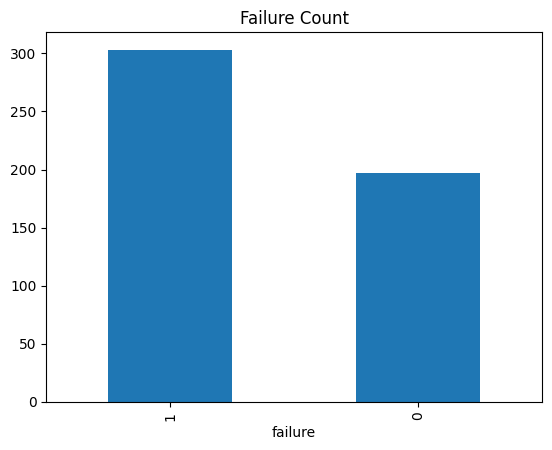

In [11]:
df['failure'].value_counts().plot(kind='bar', title="Failure Count")

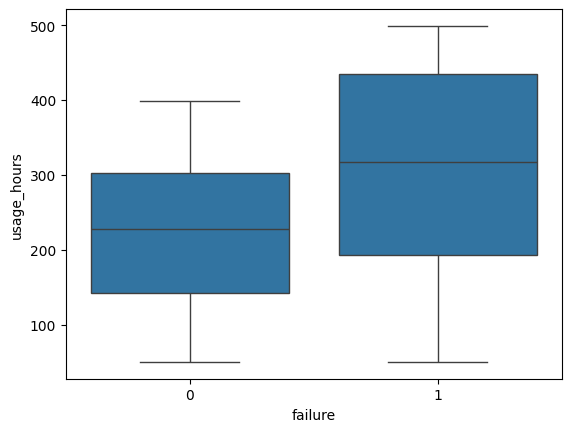

In [12]:
import seaborn as sns             #Higher usage correlates with failure
import matplotlib.pyplot as plt

sns.boxplot(x='failure', y='usage_hours', data=df)
plt.show()

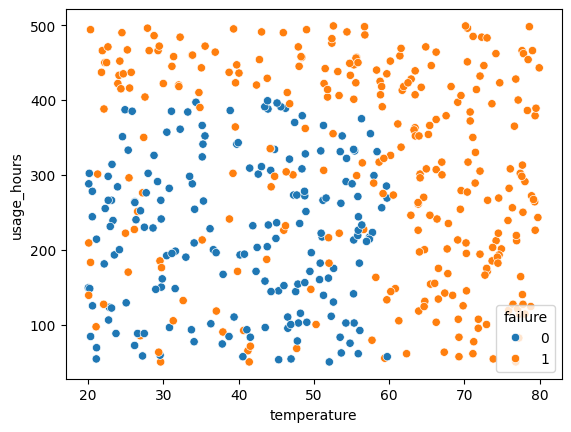

In [13]:
## Temperature Impact
sns.scatterplot(x='temperature', y='usage_hours', hue='failure', data=df)
plt.show()

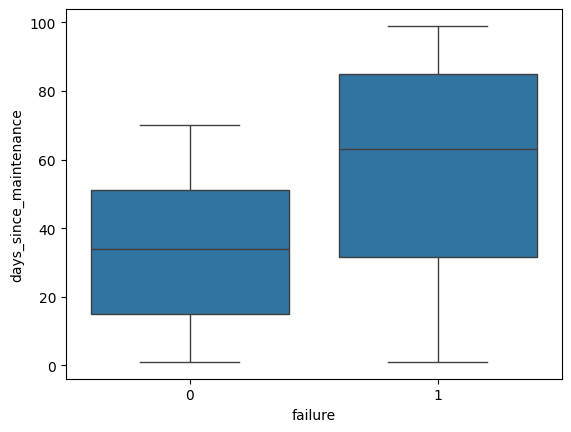

In [14]:
#Maintenance Gap Analysis
sns.boxplot(x='failure', y='days_since_maintenance', data=df)
plt.show()

In [15]:
# Risk Score
df['risk_score'] = (
    0.4 * (df['usage_hours'] / df['usage_hours'].max()) +
    0.3 * (df['days_since_maintenance'] / df['days_since_maintenance'].max()) +
    0.3 * (df['temperature'] / df['temperature'].max())
)

In [16]:
## Categorizing the Risk
def risk_label(score):
    if score > 0.7:
        return "High"
    elif score > 0.4:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['risk_score'].apply(risk_label)

## Insight Visualization

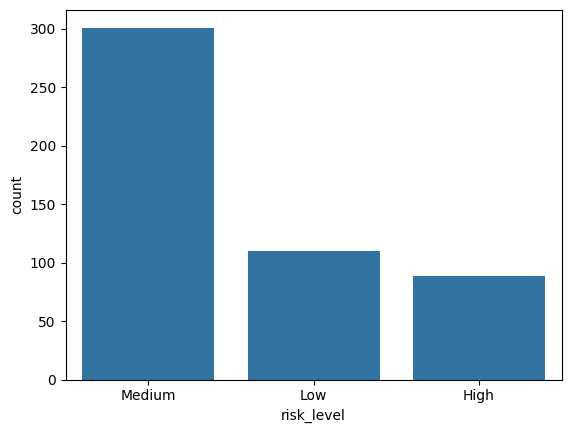

In [17]:
#Risk Level Count
sns.countplot(x='risk_level', data=df)
plt.show()

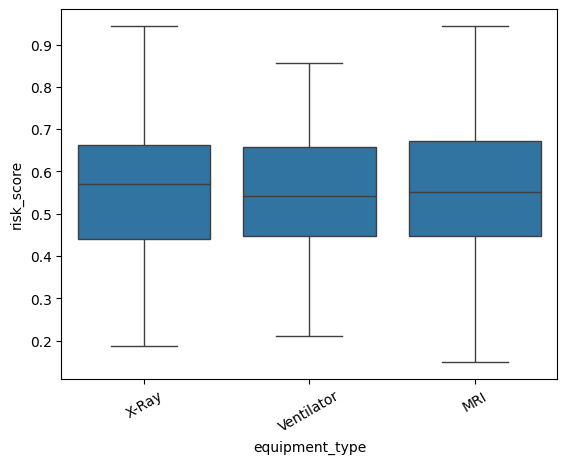

In [18]:
#Equipment Risk Comparision
sns.boxplot(x='equipment_type', y='risk_score', data=df)
plt.xticks(rotation=30)
plt.show()

In [19]:
## High risk Equipment List
df[df['risk_level'] == 'High'].head()

,equipment_id,equipment_type,usage_hours,days_since_maintenance,temperature,load,failure,risk_score,risk_level
23,24,MRI,494,84,49.025297,0.685460,1,0.834471,High
25,26,Ventilator,476,68,52.390567,0.933107,1,0.784184,High
27,28,X-Ray,317,67,70.491780,0.911238,1,0.721611,High
40,41,Ventilator,435,98,24.665921,0.636837,1,0.738209,High
49,50,MRI,459,70,61.433614,0.588127,1,0.810545,High


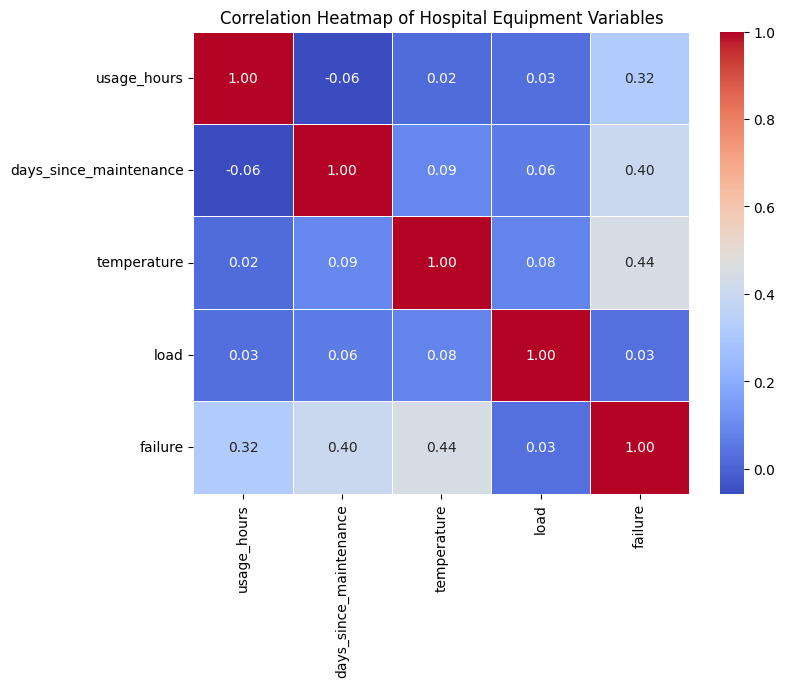

In [21]:
# Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
correlation_data = df[
    ['usage_hours',
     'days_since_maintenance',
     'temperature',
     'load',
     'failure']
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Hospital Equipment Variables')
plt.show()

**Observation: The correlation heatmap shows that temperature has the strongest positive correlation with failure (0.44), followed by days since maintenance (0.40) and usage hours (0.32). Load has almost no linear correlation with failure (0.03). The predictor variables also show very weak correlations with each other, indicating limited linear relationships among them. These correlations provide an initial understanding of the variables that may contribute to equipment failure.**

# Key Observations

### Equipment with higher usage hours consistently shows higher risk levels, indicating overuse is a major stress factor.

### Delayed maintenance strongly correlates with increased failure, suggesting maintenance scheduling is critical, not optional.
### Temperature spikes are linked with high-risk equipment, showing environmental conditions play a role in performance degradation.
### Certain equipment types (like ventilators/MRI depending on your data) cluster in higher risk categories, hinting at uneven workload distribution.
### A small portion of equipment falls into high-risk category but contributes disproportionately to failures, meaning targeted intervention could reduce system breakdowns.

## Linear Regression

Predict **usage hours** from **days since maintenance**.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Input and output
X = df[['days_since_maintenance']]
y = df['usage_hours']

# Split the data
X_train, X_test, y_train, y_test_linear = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['days_since_maintenance']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,273.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [23]:
# Make predictions
linear_predictions = linear_model.predict(X_test)

print("Actual usage hours:")
print(y_test_linear.head().values)

print("\nPredicted usage hours:")
print(linear_predictions[:5])

Actual usage hours:
[285  85 447 442 452]

Predicted usage hours:
[272.12917911 271.14908334 273.10927488 272.25483241 271.19934466]


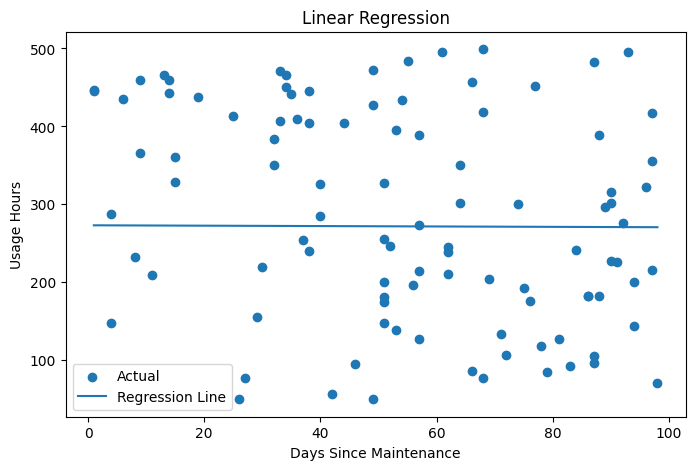

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test['days_since_maintenance'],
    y_test_linear,
    label='Actual'
)

sorted_indices = X_test['days_since_maintenance'].argsort()

plt.plot(
    X_test['days_since_maintenance'].iloc[sorted_indices],
    linear_predictions[sorted_indices],
    label='Regression Line'
)

plt.xlabel('Days Since Maintenance')
plt.ylabel('Usage Hours')
plt.title('Linear Regression')
plt.legend()
plt.show()

**The scatter plot shows the actual usage hours for different maintenance intervals. The regression line is almost flat, indicating that days since maintenance has very little linear relationship with equipment usage hours in this dataset.**

## Logistic Regression

Predict whether equipment will **fail (1)** or **not fail (0)**.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Remove rows with missing temperature values
model_df = df.dropna(subset=['temperature'])

# Input features
X = model_df[['usage_hours', 'days_since_maintenance', 'temperature']]

# Target
y = model_df['failure']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

# Predictions
logistic_predictions = logistic_model.predict(X_test)

print("Actual failure values:")
print(y_test.head().values)

print("\nPredicted failure values:")
print(logistic_predictions[:5])

Actual failure values:
[1 1 0 0 0]

Predicted failure values:
[1 1 1 0 0]


In [26]:
# Make predictions
logistic_predictions = logistic_model.predict(X_test)

print("Actual failure values:")
print(y_test.head().values)

print("\nPredicted failure values:")
print(logistic_predictions[:5])

Actual failure values:
[1 1 0 0 0]

Predicted failure values:
[1 1 1 0 0]


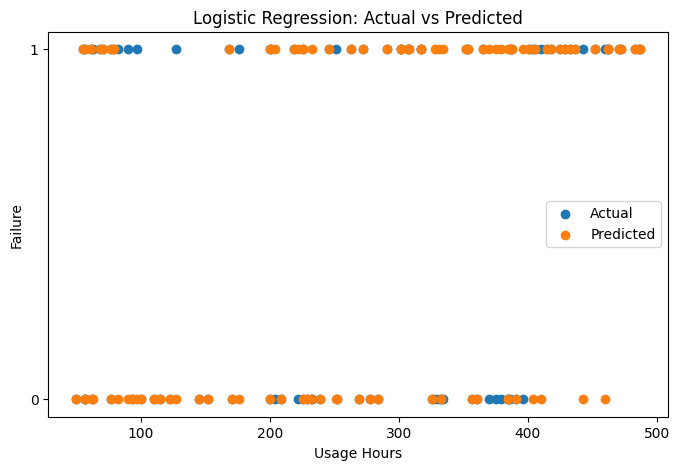

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test['usage_hours'],
    y_test,
    label='Actual'
)

plt.scatter(
    X_test['usage_hours'],
    logistic_predictions,
    label='Predicted'
)

plt.xlabel('Usage Hours')
plt.ylabel('Failure')
plt.title('Logistic Regression: Actual vs Predicted')
plt.yticks([0, 1])
plt.legend()

plt.show()

**Observation: Actual and predicted failure values show considerable overlap, indicating that the Logistic Regression model is able to capture the general pattern of equipment failure. Failures are more frequently observed at higher usage hours, while non-failures are more common at lower usage hours. However, some mismatches are present, showing that the model does not perfectly classify all equipment records.**